## Aparcamiento autónomo asistido mediante Aprendizaje por Refuerzo en un entorno continuo de Gymnasium

El agente será un vehículo que se mueve en un espacio 2D continuo. Debe aparcar en una plaza evitando colisiones con paredes y obstáculos, usando sensores de distancia simulados.

Algoritmos utilizados en principio:
- SARSA
- Q-learning
- DQN

El entorno principal será continuo, porque el problema de vehículo/aparcamiento tiene sentido como problema de control continuo. Pero para Q-Learning y SARSA necesitaremos una versión discretizada del estado.

ContinuousParkingEnv -> observación continua para DQN -> función de discretización para Q-Learning y SARSA

1) creación entorno 

ContinuousParkingEnv 

el entorno tendrá: 


Estado interno continuo: Diseño del MDP


st​=(xt​,yt​,θt​,vt​)
- x_t      = posición horizontal del coche
- y_t      = posición vertical del coche
- theta_t  = orientación del coche en radianes
- v_t      = velocidad actual

Observación continua (vector numérico):


- sensores + distancia a plaza + error angular + velocidad

In [ ]:
obs = [
    x_norm,
    y_norm,
    cos(theta),
    sin(theta),
    v_norm,
    sensor_front,
    sensor_front_left,
    sensor_front_right,
    sensor_left,
    sensor_right,
    sensor_back,
    sensor_back_left,
    sensor_back_right,
    distance_to_goal_norm,
    cos(angle_to_goal),
    sin(angle_to_goal),
    cos(orientation_error),
    sin(orientation_error),
]

Acciones discretas: (aunque el coche real tendria acciones continuas lo vamos a simular)
- avanzar, girar, retroceder, frenar

Algoritmos:
- Q-Learning y SARSA usan observación discretizada
- DQN usa observación continua

Dinámica del vehículo:
- Usamos una dinámica continua sencilla tal que cada acción define una velocidad y un giro 

In [ ]:
x(t+1) = x(t) + vcos(θt​)Δt
y(t+1) = y(t) + vsin(θt​)Δt
θ(t+1) = θ(t) + ωΔt

Cada acción define una velocida y un giro

In [ ]:
TABLA_ACCIONES= {
    0: ( 1.0,  0.0),# avanzar recto
    1: ( 1.0,  1.0),# avanzar izquierda
    2: ( 1.0, -1.0),# avanzar derecha
    3: (-1.0,  0.0),# retroceder recto
    4: (-1.0,  1.0),# retroceder izquierda
    5: (-1.0, -1.0),# retroceder derecha
    6: ( 0.0,  0.0),# frenar
}

Implementación del entorno Gymnasium personalizado (heredando de gym.Env) con: 
- reset()
- step(action)
- render()
- close()

Recompensa inicial:

In [ ]:
reward = -0.05  # penalización por paso

reward += 2.0 * (previous_distance_to_goal - current_distance_to_goal)
reward += 0.5 * (previous_orientation_error - current_orientation_error)

if min_sensor_distance < 0.15:
    reward -= 2.0

if collision:
    reward -= 100.0
    terminated = True

if parked:
    reward += 100.0
    terminated = True

if action == 6 and not parked:
    reward -= 1.0

- Premiamos acercarse a la plaza.
- Premiamos alinearse con la orientación objetivo.
- Penalizamos acercarse demasiado a obstáculos.
- Penalizamos mucho colisionar.
- Premiamos mucho aparcar correctamente.
- Penalizamos frenar sin estar aparcado.

Vamos a definir "aparcar" como: 

In [ ]:
parked = (
    distance_to_goal < 0.35 and
    abs(orientation_error) < 0.25 and
    abs(self.v) < 0.05 and
    action == 6
)

El resultado de nuestro entorno configurado es:

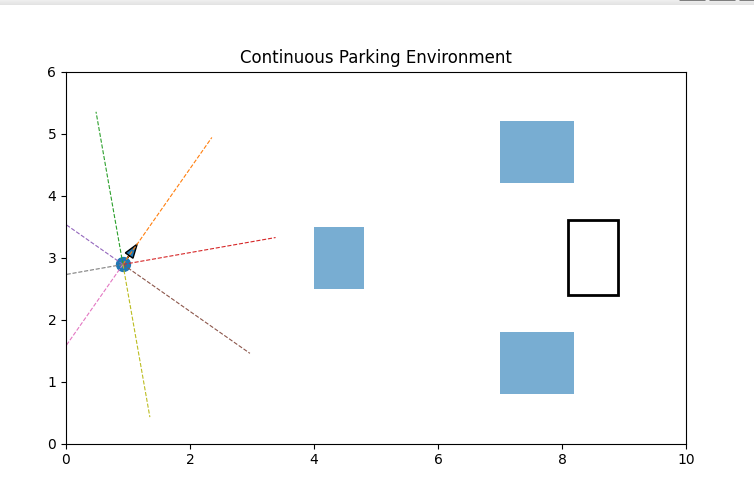

Usaremos el mismo entorno para 3 algoritmos distintos:
- DQN usara la observación continua directamente 
- Q-learning y SARSA no pueden usar directamente el vector continuo porque necesitarian una tabla (Q-table) muy grande entonces tendremos que discretizar y quedarnos con las variables mas importantes y las convertimos a intervalos 

# PASOS:

- crear entorno virtual 
- crear requirements.txt
- crear estructura de carpetas 
- fase 1: entorno continuo funcionando 
- fase 2: script prueba aleatoria 
- fase 3: discretizacion
- fase 4: Q -learning (agente y train)
- fase 5: SARSA (agente y train)
- fase 6: DQN (replay_buffer, networks, agente dqn, train)
- fase 7: comparar los 3 con las mismas metricas (recompensa por episodio,tasa de éxito, tasa de colisión, pasos medios, distancia final a la plaza, epsilon)

primera posible versión del entorno:
- Mundo: 10 x 6 metros
- Vehículo: punto orientado
- Plaza: centro en (8.5, 3.0)
- Orientación objetivo: pi / 2
- Obstáculos: rectángulos sencillos
- Sensores: 8 rayos
- Máximo de pasos: 300
- Acciones: 7 discretas
- Observación: Box de 18 valores

In [1]:
import sys
print(sys.executable)

/mnt/c/Users/laura/OneDrive/Escritorio/TERCERO 2º CUATRI CCDD/AAII/RL/parking_rl/.venv/bin/python


En principio para la fase 3 de discretizacion estamos reduciendo la observacion a las variables discretas importantes:
- distancia al objetivo
- ángulo hacia el objetivo
- error de orientación
- sensores principales
- velocidad

Eso seria la clave de la tabla Q[state][action]

## fase 4) ALGORITMO Q-LEARNING

La idea es 
- obs continua del entorno
- discretize_obs(obs)
- estado discreto tipo tupla como ya hemos comprobado al probar en tarn_random.py
- Q[state][action]

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results/qlearning_results.csv")

df["reward_ma"] = df["reward"].rolling(100).mean()
df["success_ma"] = df["success"].rolling(100).mean()
df["collision_ma"] = df["collision"].rolling(100).mean()
df["steps_ma"] = df["steps"].rolling(100).mean()
df["final_distance_ma"] = df["final_distance"].rolling(100).mean()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["reward"], alpha=0.25, label="Reward")
plt.plot(df["episode"], df["reward_ma"], label="Reward media móvil 100")
plt.xlabel("Episodio")
plt.ylabel("Recompensa")
plt.title("Q-Learning - Recompensa por episodio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["success_ma"], label="Tasa éxito media móvil 100")
plt.xlabel("Episodio")
plt.ylabel("Tasa de éxito")
plt.title("Q-Learning - Tasa de éxito")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["collision_ma"], label="Tasa colisión media móvil 100")
plt.xlabel("Episodio")
plt.ylabel("Tasa de colisión")
plt.title("Q-Learning - Colisiones")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["steps_ma"], label="Pasos medios")
plt.xlabel("Episodio")
plt.ylabel("Pasos")
plt.title("Q-Learning - Pasos por episodio")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(df["episode"], df["final_distance_ma"], label="Distancia final media")
plt.xlabel("Episodio")
plt.ylabel("Distancia final a la plaza")
plt.title("Q-Learning - Distancia final al objetivo")
plt.legend()
plt.grid(True)
plt.show()

AttributeError: module 'matplotlib' has no attribute 'backends'

Error in callback <function _enable_matplotlib_integration.<locals>.configure_once at 0x73bd49551b20> (for post_run_cell), with arguments args (<ExecutionResult object at 73bd49bd7740, execution_count=2 error_before_exec=None error_in_exec=module 'matplotlib' has no attribute 'backends' info=<ExecutionInfo object at 73bd49bd7500, raw_cell="import pandas as pd
import matplotlib.pyplot as pl.." transformed_cell="import pandas as pd
import matplotlib.pyplot as pl.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://wsl%2Bubuntu-24.04/mnt/c/Users/laura/OneDrive/Escritorio/TERCERO%202%C2%BA%20CUATRI%20CCDD/AAII/RL/parking_rl/pruebas.ipynb#X24sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


AttributeError: module 'matplotlib' has no attribute 'backends'

In [ ]:
import matplotlib
print(matplotlib.__version__)
print(matplotlib.__file__)

: 